In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage[T1]{fontenc} \usepackage{polski} \usepackage[utf8]{inputenc}'
})
figsize = (6, 3)
new_orange = '#ff5500'

#### Zadanie 1.
W ankiecie przedstawionej na poprzedniej liście pracownicy zostali poproszeni o wyrażenie opinii na temat skuteczności szkolenia "Efektywna komunikacja w zespole" zorganizowanego przez firmę. Wśród próbki 200 pracowników (losowanie proste ze zwracaniem) uzyskano wyniki:

- 14 pracowników - bardzo niezadowolonych,
- 17 pracowników - niezadowolonych,
- 40 pracowników - nie ma zdania,
- 100 pracowników - zadowolonych,
- 29 pracowników - bardzo zadowolonych.

Na podstawie danych wyznacz przedział ufności dla wektora prawdopodobieństw opisującego stopień zadowolenia ze szkolenia. Przyjmij poziom ufności 0.95.

<>:51: SyntaxWarning: invalid escape sequence '\%'
<>:51: SyntaxWarning: invalid escape sequence '\%'
/var/folders/md/bjv2qqp906q0tvtbwsrkfkw00000gn/T/ipykernel_38037/3602667356.py:51: SyntaxWarning: invalid escape sequence '\%'
  ax.set_title('Ocena szkolenia - wektor prawdopodobieństw z 95\% przedziałem ufności')


Tabela przedziałów ufności:
              Opinia  n_i  p_hat  Dolna granica (95%)  Górna granica (95%)
Bardzo niezadowoleni   14  0.070               0.0235               0.1165
       Niezadowoleni   17  0.085               0.0342               0.1358
       Nie ma zdania   40  0.200               0.1271               0.2729
          Zadowoleni  100  0.500               0.4089               0.5911
   Bardzo zadowoleni   29  0.145               0.0809               0.2091


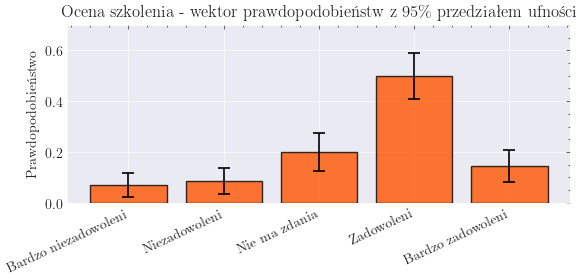

In [3]:
# --- Dane z Zadania 1 ---
n = 200
counts = np.array([14, 17, 40, 100, 29])
k = len(counts) # liczba kategorii (5)
labels = [
    'Bardzo niezadowoleni',
    'Niezadowoleni',
    'Nie ma zdania',
    'Zadowoleni',
    'Bardzo zadowoleni'
]

# 1. Frakcje z próby (estymatory punktowe)
p_hat = counts / n

# 2. Kwantyl rozkładu normalnego z poprawką Bonferroniego
alpha = 0.05
# Dzielimy poziom istotności przez k, by uzyskać jednoczesny przedział dla całego wektora
z_val = scipy.stats.norm.ppf(1 - alpha / (2 * k))

# 3. Błąd standardowy i margines błędu
se = np.sqrt((p_hat * (1 - p_hat)) / n)
margin_of_error = z_val * se

# 4. Dolna i górna granica (przycinamy do [0, 1] dla pewności)
ci_lower = np.maximum(0, p_hat - margin_of_error)
ci_upper = np.minimum(1, p_hat + margin_of_error)

# --- Podsumowanie w tabeli Pandas ---
df_results = pd.DataFrame({
    'Opinia': labels,
    'n_i': counts,
    'p_hat': p_hat,
    'Dolna granica (95%)': ci_lower.round(4),
    'Górna granica (95%)': ci_upper.round(4)
})

print("Tabela przedziałów ufności:")
print(df_results.to_string(index=False))

# --- Wykres ---
fig, ax = plt.subplots(figsize=figsize)

# Słupki z wąsami błędu (error bars)
x_pos = np.arange(k)
ax.bar(x_pos, p_hat, yerr=margin_of_error, capsize=4,
       color=new_orange, edgecolor='black', alpha=0.8,
       error_kw={'elinewidth': 1.2, 'capthick': 1.2})

ax.set_ylabel('Prawdopodobieństwo')
ax.set_title('Ocena szkolenia - wektor prawdopodobieństw z 95\% przedziałem ufności')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_ylim(0, 0.7) # Ustawione sztywno by ładnie zmieścić wąsy

plt.tight_layout()
plt.show()

### Zadanie 3

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

# --- Funkcja z Zadania 2 ---
def p_value_multinomial(x, p0):
    x = np.array(x)
    p0 = np.array(p0)

    if len(x) != len(p0):
        raise ValueError("Błąd: Wektor obserwacji x i wektor prawdopodobieństw p0 muszą mieć taką samą długość.")

    n = np.sum(x)
    k = len(x)
    df = k - 1

    E = n * p0

    chi2_pearson = np.sum((x - E)**2 / E)
    p_val_pearson = chi2.sf(chi2_pearson, df)

    idx = x > 0
    chi2_lr = 2 * np.sum(x[idx] * np.log(x[idx] / E[idx]))
    p_val_lr = chi2.sf(chi2_lr, df)

    wyniki = pd.DataFrame({
        'Statystyka': [chi2_pearson, chi2_lr],
        'p-value': [p_val_pearson, p_val_lr],
        'Stopnie swobody': [df, df]
    }, index=['Chi-kwadrat Pearsona', 'Iloraz wiarogodności (G-test)'])

    return wyniki

# --- Rozwiązanie Zadania 3 ---

# 1. Wczytanie danych z pliku (podmień 'dane.csv' na właściwą nazwę swojego pliku)
# Używamy sep=';' zgodnie z podaną przez Ciebie strukturą
df = pd.read_csv('dane.csv', sep=';')

# 2. Przefiltrowanie danych tylko dla konkretnego działu
# UWAGA: Upewnij się czy w pliku masz 'Produktowy', 'Produkcja' czy inną nazwę.

# To pokaże Ci wszystkie unikalne nazwy działów w Twoim pliku
print("Dostępne działy w pliku:", df['DZIAŁ'].unique())

nazwa_dzialu = 'PD'
df_dzial = df[df['DZIAŁ'] == nazwa_dzialu]

# 3. Zliczenie wystąpień poszczególnych odpowiedzi dla PYT_1
# Kodowanie: -2, -1, 0, 1, 2
mozliwe_odpowiedzi = [-2, -1, 0, 1, 2]

# value_counts() zlicza odpowiedzi, a reindex zapewnia, że braki zostaną uzupełnione 0.
zliczenia = df_dzial['PYT_1'].value_counts().reindex(mozliwe_odpowiedzi, fill_value=0).values

# 4. Ustalenie parametrów hipotezy i testowanie
# H0: Rozkład jest równomierny, więc każde z 5 zdarzeń ma szansę p=0.2
prawdopodobienstwa_H0 = [0.2, 0.2, 0.2, 0.2, 0.2]
alpha = 0.05

print(f"Analiza dla działu: {nazwa_dzialu}")
print(f"Liczebności odpowiedzi dla kategorii [-2, -1, 0, 1, 2]: {zliczenia}")
print("-" * 50)

# Wywołanie Twojej funkcji
wyniki_testu = p_value_multinomial(x=zliczenia, p0=prawdopodobienstwa_H0)
print(wyniki_testu)
print("-" * 50)

# 5. Wnioskowanie na podstawie p-value z testu Pearsona (można użyć dowolnego)
p_val = wyniki_testu.loc['Chi-kwadrat Pearsona', 'p-value']

print(f"Poziom istotności (alpha) = {alpha}")
print(f"Otrzymane p-value (Pearson) = {p_val:.4f}")

if p_val < alpha:
    print("Wniosek: Odrzucamy hipotezę zerową (H0).")
    print("Rozkład odpowiedzi NIE jest równomierny.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej (H0).")
    print("Możemy przyjąć, że rozkład odpowiedzi jest równomierny.")

Dostępne działy w pliku: ['IT' 'PD' 'MK' 'HR']
Analiza dla działu: PD
Liczebności odpowiedzi dla kategorii [-2, -1, 0, 1, 2]: [ 9 10 17 51 11]
--------------------------------------------------
                               Statystyka       p-value  Stopnie swobody
Chi-kwadrat Pearsona            64.857143  2.757834e-13                4
Iloraz wiarogodności (G-test)   52.527114  1.070199e-10                4
--------------------------------------------------
Poziom istotności (alpha) = 0.05
Otrzymane p-value (Pearson) = 0.0000
Wniosek: Odrzucamy hipotezę zerową (H0).
Rozkład odpowiedzi NIE jest równomierny.


### Zadanie 5

library(dplyr)
library(knitr) # do wygenerowania ładnej tabelki, idealne do Quarto/RMarkdown

# Zakładam, że Twoja ramka danych nazywa się 'ankieta'
# i że wykonałeś/aś już blok kodu z case_when() tworzący 'CZY_ZADOW'
library(dplyr)


ankieta <- read.csv("ankieta2.csv", sep=";")
colnames(ankieta) <- c("DZIAŁ", "STAŻ", "CZY_KIER", "PYT_1", "PYT_2", "PYT_3", "PŁEĆ", "WIEK")
anyNA(ankieta) # nie ma braków w danych
unique(ankieta$DZIAŁ)
unique(ankieta$STAŻ)
unique(ankieta$CZY_KIER)
unique(ankieta$PYT_1)
unique(ankieta$PYT_2)
unique(ankieta$PŁEĆ)
unique(ankieta$WIEK)
# 2. Utworzenie zmiennej CZY_ZADOW (Twój kod z zadania 1)

ankieta <- ankieta |> mutate("WIEK_KAT" = cut(
  WIEK,
  breaks = c(0, 35, 45, 55, Inf),
  labels = c("do 35 lat", "między 36 a 45 lat", "między 46 a 55 lat", "powyżej 55 lat")
))

ankieta <- ankieta |>
  mutate(CZY_ZADOW = case_when(
    PYT_2 %in% c(-2, -1) ~ "niezadowolony",
    PYT_2 %in% c(1, 2) ~ "zadowolony",
    TRUE ~ NA_character_
  ))

# 1. Funkcja pomocnicza ułatwiająca przeprowadzenie testu i sformatowanie wyniku
wykonaj_test_fishera <- function(dane, var1, var2) {
  # Filtrujemy braki danych (żeby NA nie weszły nam do tabeli krzyżowej)
  dane_clean <- dane |>
    filter(!is.na(.data[[var1]]), !is.na(.data[[var2]]))

  # Tworzymy tabelę krzyżową (kontyngencji)
  tabela <- table(dane_clean[[var1]], dane_clean[[var2]])

  # Wykonujemy test.
  # simulate.p.value = TRUE to standard przy teście Freemana-Haltona (tabele > 2x2)
  # B = 10000 to liczba powtórzeń symulacji (domyślnie jest to 2000, 10000 daje większą dokładność)
  test <- fisher.test(tabela, simulate.p.value = TRUE, B = 10000)

  p_val <- test$p.value

  # Decyzja dla poziomu istotności 0.05
  decyzja <- ifelse(p_val < 0.05,
                    "Odrzucamy H0 (Zależne)",
                    "Nie odrzucamy H0 (Niezależne)")

  # Zwracamy wynik jako jeden wiersz ramki danych
  data.frame(
    Badana_para = paste(var1, "vs", var2),
    p_value = round(p_val, 4),
    Wniosek = decyzja
  )
}

# 2. Definiujemy listy z hipotezami do sprawdzenia
pary_podstawowe <- list(
  c("CZY_KIER", "WIEK_KAT"), # a)
  c("CZY_KIER", "STAŻ"),     # b)
  c("PYT_2", "CZY_KIER"),    # c)
  c("PYT_2", "STAŻ"),        # d)
  c("PYT_2", "PŁEĆ"),        # e)
  c("PYT_2", "WIEK_KAT")     # f)
)

pary_zadowolenie <- list(
  c("CZY_ZADOW", "CZY_KIER"), # c) ze zmienioną zmienną
  c("CZY_ZADOW", "STAŻ"),     # d) ze zmienioną zmienną
  c("CZY_ZADOW", "PŁEĆ"),     # e) ze zmienioną zmienną
  c("CZY_ZADOW", "WIEK_KAT")  # f) ze zmienioną zmienną
)

# 3. Odpalamy pętle po naszych listach za pomocą lapply, a wynik spinamy w ramkę danych za pomocą bind_rows()
wyniki_podstawowe <- lapply(pary_podstawowe, function(x) wykonaj_test_fishera(ankieta, x[1], x[2])) |> bind_rows()
wyniki_zadowolenie <- lapply(pary_zadowolenie, function(x) wykonaj_test_fishera(ankieta, x[1], x[2])) |> bind_rows()

# 4. Łączymy w jedną wielką tabelę podsumowującą
tabela_koncowa <- bind_rows(
  wyniki_podstawowe |> mutate(Wariant = "Oryginalne PYT_2"),
  wyniki_zadowolenie |> mutate(Wariant = "Przekształcone CZY_ZADOW")
) |>
  select(Wariant, Badana_para, p_value, Wniosek) # Zamiana kolejności kolumn by lepiej to wyglądało

# 5. Wyświetlamy jako ładną tabelę Markdown (przydatne do raportu HTML/PDF)
kable(tabela_koncowa, align = c('l', 'c', 'c', 'c'), caption = "Wyniki testu Fishera (Freemana-Haltona)")

```



\begin{table}[]
\begin{tabular}{|l|l|l|l|}
\hline
\textbf{Wariant}          & \textbf{Badana\_para}   & \textbf{p\_value} & \textbf{Wniosek}              \\ \hline
Oryginalne PYT\_2         & CZY\_KIER vs WIEK\_KAT  & 0.7841            & Nie odrzucamy H0 (Niezależne) \\ \hline
Oryginalne PYT\_2         & CZY\_KIER vs STAŻ       & 0.0002            & Odrzucamy H0 (Zależne)        \\ \hline
Oryginalne PYT\_2         & PYT\_2 vs CZY\_KIER     & 0.0427            & Odrzucamy H0 (Zależne)        \\ \hline
Oryginalne PYT\_2         & PYT\_2 vs STAŻ          & 0.0109            & Odrzucamy H0 (Zależne)        \\ \hline
Oryginalne PYT\_2         & PYT\_2 vs PŁEĆ          & 0.4716            & Nie odrzucamy H0 (Niezależne) \\ \hline
Oryginalne PYT\_2         & PYT\_2 vs WIEK\_KAT     & 0.3168            & Nie odrzucamy H0 (Niezależne) \\ \hline
Przekształcone CZY\_ZADOW & CZY\_ZADOW vs CZY\_KIER & 0.8377            & Nie odrzucamy H0 (Niezależne) \\ \hline
Przekształcone CZY\_ZADOW & CZY\_ZADOW vs STAŻ      & 0.4001            & Nie odrzucamy H0 (Niezależne) \\ \hline
Przekształcone CZY\_ZADOW & CZY\_ZADOW vs PŁEĆ      & 0.6589            & Nie odrzucamy H0 (Niezależne) \\ \hline
Przekształcone CZY\_ZADOW & CZY\_ZADOW vs WIEK\_KAT & 0.3316            & Nie odrzucamy H0 (Niezależne) \\ \hline
\end{tabular}
\caption{Wyniki testu Fishera (Freemana-Haltona)}
\label{tab:wyniki-zad5}
\end{table}

### zadanie 7

In [5]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# --- 1. Nasza nowa funkcja do testu ilorazu wiarogodności (Zadanie 7) ---
def lr_test_independence(observed_table):
    """
    Oblicza statystykę G oraz p-value dla testu niezależności opartego
    na ilorazie wiarogodności dla tablicy dwudzielczej.
    """
    # Konwersja do macierzy numpy dla łatwiejszych obliczeń
    O = np.array(observed_table)

    # Obliczenie sum brzegowych i całkowitej liczebności
    row_sums = O.sum(axis=1)
    col_sums = O.sum(axis=0)
    total = O.sum()

    # Wyznaczenie macierzy wartości oczekiwanych (E)
    # np.outer mnoży każdy element row_sums przez każdy element col_sums
    E = np.outer(row_sums, col_sums) / total

    # Obliczenie stopni swobody: (liczba_wierszy - 1) * (liczba_kolumn - 1)
    df = (O.shape[0] - 1) * (O.shape[1] - 1)

    # Obliczenie statystyki G (omijamy zera w obserwacjach, by uniknąć błędu log(0))
    mask = O > 0
    G = 2 * np.sum(O[mask] * np.log(O[mask] / E[mask]))

    # Obliczenie p-value z użyciem funkcji przeżycia (survival function) rozkładu chi-kwadrat
    p_value = stats.chi2.sf(G, df)

    return G, p_value, df

# --- 2. Wykonanie zadania z wykorzystaniem Twoich danych (Zadanie 6/7) ---

# Wczytanie danych i przygotowanie (Twój kod)
df = pd.read_csv('ankieta2.csv', sep=';')
df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

# Generowanie tablicy krzyżowej
tablica_krzyzowa = pd.crosstab(df['PYT_2'], df['CZY_KIER'])

print("--- Tablica krzyżowa (Obserwacje) ---")
print(tablica_krzyzowa)
print("-" * 50)

# Wywołanie naszej funkcji
G_stat, p_val_lr, stopnie_swobody = lr_test_independence(tablica_krzyzowa)

print("--- Wyniki Testu Ilorazu Wiarogodności (G-test) ---")
print(f"Statystyka G: {G_stat:.4f}")
print(f"Stopnie swobody: {stopnie_swobody}")
print(f"p-value:      {p_val_lr:.4f}")
print("-" * 50)

# Wnioskowanie
alpha = 0.05
if p_val_lr < alpha:
    print("Wniosek: Odrzucamy H0.")
    print("Zmienne PYT_2 i CZY_KIER są ZALEŻNE.")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0.")
    print("Zmienne PYT_2 i CZY_KIER są NIEZALEŻNE.")

# --- Ciekawostka: weryfikacja wbudowaną funkcją ---
# Funkcja chi2_contingency z parametrem lambda_="log-likelihood" robi dokładnie to samo!
# Odkomentuj poniżej, żeby sprawdzić, czy nasza ręczna funkcja liczy idealnie:
# stat_scipy, p_scipy, dof_scipy, _ = stats.chi2_contingency(tablica_krzyzowa, lambda_="log-likelihood")
# print(f"\n[Dla sprawdzenia - wynik ze scipy]: G={stat_scipy:.4f}, p={p_scipy:.4f}")

--- Tablica krzyżowa (Obserwacje) ---
CZY_KIER  Nie  Tak
PYT_2             
-2         64   10
-1         18    2
 1          0    2
 2         91   13
--------------------------------------------------
--- Wyniki Testu Ilorazu Wiarogodności (G-test) ---
Statystyka G: 8.3285
Stopnie swobody: 3
p-value:      0.0397
--------------------------------------------------
Wniosek: Odrzucamy H0.
Zmienne PYT_2 i CZY_KIER są ZALEŻNE.


# zadanie 9

In [6]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# --- 1. Funkcja do obliczania współczynnika Gamma Goodmana-Kruskala ---
def goodman_kruskal_gamma(x, y):
    """
    Oblicza współczynnik Gamma dla dwóch wektorów zmiennych porządkowych.
    """
    # Tworzymy tablicę krzyżową
    crosstab = pd.crosstab(x, y)

    nc = 0 # Pary zgodne (concordant)
    nd = 0 # Pary niezgodne (discordant)

    # Przechodzimy przez każdą komórkę tabeli
    for i in range(crosstab.shape[0]):
        for j in range(crosstab.shape[1]):
            # Pary zgodne: suma wartości na prawo i w dół
            nc += crosstab.iloc[i, j] * crosstab.iloc[i+1:, j+1:].sum().sum()
            # Pary niezgodne: suma wartości na lewo i w dół
            nd += crosstab.iloc[i, j] * crosstab.iloc[i+1:, :j].sum().sum()

    # Wzór na Gammę: (Nc - Nd) / (Nc + Nd)
    if (nc + nd) == 0:
        return 0 # Zabezpieczenie przed dzieleniem przez zero

    return (nc - nd) / (nc + nd)

# --- 2. Przygotowanie danych (Zadanie 9) ---
# Zakładam, że masz już wczytany dataframe 'df'
# df = pd.read_csv('ankieta2.csv', sep=';')
# df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

# Kopiujemy dane, by nie psuć oryginalnego dataframe'u
df_analiza = df.copy()

# Zamieniamy 'Nie'/'Tak' na 0/1 w kolumnie CZY_KIER
# Usuwamy też ewentualne braki danych, żeby testy nie wyrzuciły błędów
df_analiza['CZY_KIER_NUM'] = df_analiza['CZY_KIER'].map({'Nie': 0, 'Tak': 1})
df_analiza = df_analiza.dropna(subset=['PYT_2', 'STAŻ', 'CZY_KIER_NUM'])

# --- 3. Definiujemy pary do zbadania ---
pary = [
    ('PYT_2', 'CZY_KIER_NUM', 'Zadowolenie vs Stanowisko'),
    ('PYT_2', 'STAŻ', 'Zadowolenie vs Staż pracy'),
    ('CZY_KIER_NUM', 'STAŻ', 'Stanowisko vs Staż pracy')
]

# --- 4. Obliczenia i prezentacja ---
wyniki = []

for var1, var2, opis in pary:
    x = df_analiza[var1]
    y = df_analiza[var2]

    # Współczynnik Kendall Tau-b (wbudowany w bibliotekę SciPy - idealny dla danych z wieloma powtórzeniami)
    tau, p_val_tau = stats.kendalltau(x, y)

    # Współczynnik Gamma Goodmana-Kruskala (z naszej funkcji)
    gamma = goodman_kruskal_gamma(x, y)

    wyniki.append({
        'Badana relacja': opis,
        'Zmienne': f"{var1} & {var2}",
        'Kendall Tau-b': round(tau, 4),
        'Gamma': round(gamma, 4),
        'p-value (dla Tau)': round(p_val_tau, 4)
    })

# Wyświetlamy jako ładną ramkę danych
df_wyniki = pd.DataFrame(wyniki)
print("--- Miary współzmienności dla zmiennych porządkowych ---")
print(df_wyniki.to_string(index=False))

--- Miary współzmienności dla zmiennych porządkowych ---
           Badana relacja              Zmienne  Kendall Tau-b   Gamma  p-value (dla Tau)
Zadowolenie vs Stanowisko PYT_2 & CZY_KIER_NUM        -0.0130 -0.0341             0.8486
Zadowolenie vs Staż pracy         PYT_2 & STAŻ         0.0481  0.0908             0.4672
 Stanowisko vs Staż pracy  CZY_KIER_NUM & STAŻ         0.2816  0.7527             0.0000


# zadanie dodatkowe 1

In [7]:
import numpy as np

# --- 1. Funkcja do obliczania Korelacji Odległości (Distance Correlation) ---
def distance_correlation(X, Y):
    # Upewniamy się, że to wektory numpy
    X = np.atleast_1d(X)
    Y = np.atleast_1d(Y)

    n = len(X)

    # Krok 1: Macierze odległości euklidesowej (każdy punkt z każdym)
    a = np.abs(X[:, None] - X[None, :])
    b = np.abs(Y[:, None] - Y[None, :])

    # Krok 2: Podwójne centrowanie macierzy
    A = a - a.mean(axis=0)[None, :] - a.mean(axis=1)[:, None] + a.mean()
    B = b - b.mean(axis=0)[None, :] - b.mean(axis=1)[:, None] + b.mean()

    # Krok 3: Wyliczenie kowariancji i wariancji odległości
    dcov2_xy = np.sum(A * B) / (n**2)
    dcov2_xx = np.sum(A * A) / (n**2)
    dcov2_yy = np.sum(B * B) / (n**2)

    # Krok 4: Korelacja odległości (pierwiastek z dCov^2(X,Y) / sqrt(dCov^2(X) * dCov^2(Y)))
    if dcov2_xx > 0 and dcov2_yy > 0:
        dcor = np.sqrt(np.maximum(dcov2_xy, 0) / np.sqrt(dcov2_xx * dcov2_yy))
    else:
        dcor = 0.0

    return dcor

# --- 2. Funkcja do testowania i wyliczania p-value (Test Permutacyjny) ---
def dcor_test(X, Y, num_permutations=1000):
    """
    Wylicza p-value dla testu niezależności opartego na korelacji odległości.
    """
    # Rzeczywista korelacja odległości dla naszych danych
    obs_dcor = distance_correlation(X, Y)

    count_greater = 0
    Y_permuted = np.copy(Y)

    # Tasujemy wektor Y i sprawdzamy, czy przypadek wygeneruje większą korelację
    for _ in range(num_permutations):
        np.random.shuffle(Y_permuted)
        perm_dcor = distance_correlation(X, Y_permuted)

        if perm_dcor >= obs_dcor:
            count_greater += 1

    # Obliczamy p-value (dodajemy 1 w liczniku i mianowniku, co jest standardem w testach permutacyjnych)
    p_value = (count_greater + 1) / (num_permutations + 1)

    return obs_dcor, p_value

# --- 3. Generowanie danych i weryfikacja hipotezy ---

np.random.seed(42) # Dla powtarzalności wyników
n_samples = 100

print("=== SCENARIUSZ 1: Zmienne CAŁKOWICIE NIEZALEŻNE ===")
X_indep = np.random.normal(0, 1, n_samples)
Y_indep = np.random.normal(0, 1, n_samples)

dcor_val, p_val = dcor_test(X_indep, Y_indep)

print(f"Korelacja odległości: {dcor_val:.4f}")
print(f"p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Wniosek: Odrzucamy H0 (Są zależne!)")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0 (Są niezależne - uff, wszystko działa!)")


print("\n=== SCENARIUSZ 2: Zmienne ZALEŻNE NIELINIOWO (Parabola) ===")
# Generujemy X, a Y jest kwadratem X plus trochę szumu
X_dep = np.random.uniform(-3, 3, n_samples)
Y_dep = X_dep**2 + np.random.normal(0, 0.5, n_samples)

dcor_val2, p_val2 = dcor_test(X_dep, Y_dep)

print(f"Korelacja odległości: {dcor_val2:.4f}")
print(f"p-value: {p_val2:.4f}")

# Zwykła korelacja Pearsona dla porównania
pearson_corr = np.corrcoef(X_dep, Y_dep)[0, 1]
print(f"Dla porównania, zwykła korelacja Pearsona wynosi: {pearson_corr:.4f} (bliska 0!)")

if p_val2 < 0.05:
    print("Wniosek: Odrzucamy H0 (Są zależne - dCor pięknie wyłapał nieliniowość!)")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0.")

=== SCENARIUSZ 1: Zmienne CAŁKOWICIE NIEZALEŻNE ===
Korelacja odległości: 0.1903
p-value: 0.2507
Wniosek: Brak podstaw do odrzucenia H0 (Są niezależne - uff, wszystko działa!)

=== SCENARIUSZ 2: Zmienne ZALEŻNE NIELINIOWO (Parabola) ===
Korelacja odległości: 0.5061
p-value: 0.0010
Dla porównania, zwykła korelacja Pearsona wynosi: -0.1250 (bliska 0!)
Wniosek: Odrzucamy H0 (Są zależne - dCor pięknie wyłapał nieliniowość!)
